# 5.3 — SBR and UPDRS-III PCA Analysis

## Objective
This notebook produces two sets of enriched clinical features that replace
and extend the variables used in notebook 5.1:

1. **New SBR PCA** — the Xing Core Lab quantification provides 16 detailed
   regional dopamine measurements (8 left + 8 right hemisphere) instead of
   the previous 6 columns. PCA extracts 3 components capturing overall
   signal, asymmetry, and regional variation.

2. **UPDRS-III PCA** — running PCA on the 33 individual motor examination
   items (excluding NP3TOT) extracts a laterality component (PC2) that
   captures which side of the body is more affected — a clinically meaningful
   dimension of Parkinson's not available from NP3TOT alone.

## What this notebook does
1. Loads the Xing Core Lab SBR file and filters failed acquisitions
2. Runs PCA on 16 regional SBR columns — fits on train, applies to val
3. Saves fitted SBR PCA objects for reuse in downstream notebooks
4. Loads UPDRS-III individual items (OFF state, excluding NP3TOT)
5. Runs PCA on all NP3* items — fits on train, applies to val
6. Verifies PC1 ≈ NP3TOT (sanity check)
7. Interprets PC2 as the laterality component
8. Saves updated train.csv and val.csv with all new PCA columns

## Outputs
- Updated train.csv and val.csv with SBR_PC1/2/3 and NP3_PC1/2/3
- results/models/scaler_sbr_xing.pkl
- results/models/pca_sbr_xing.pkl
- results/models/scaler_np3.pkl
- results/models/pca_np3.pkl
- results/figures/sbr_pca_variance.png
- results/figures/np3_pca_variance.png
- results/figures/np3_pc1_vs_np3tot.png

## 1. Imports and Configuration

In [43]:
# [IMPORTS]

import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [44]:
# [CONFIG]

# BETA_SUFFIX = 'beta_3e5'

# ── File paths ──────────────────────────────────────────────────────────────
# TRAIN_FILE    = f'../../data/processed/clinical_merged/train.csv'
# VAL_FILE      = f'../../data/processed/clinical_merged/val.csv'
SBR_XING_FILE = '../../data/raw/ppmi_clinical/Xing_Core_Lab_-_Quant_SBR_20Jul2026.csv'
UPDRS_III_FILE = '../../data/raw/ppmi_clinical/MDS-UPDRS_Part_III_06Jul2026.csv'

MODELS_DIR  = '../../results/models/'
FIGURES_DIR = '../../results/figures/'
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Parameters ──────────────────────────────────────────────────────────────
PATIENT_COL  = 'PATNO'
N_SBR_PCS    = 3   # 3 components to be sufficient
N_NP3_PCS    = 3   # PC1 = overall severity, PC2 = laterality, PC3 = check

# 16 regional SBR columns (8 left + 8 right)
SBR_XING_COLS = [
    'PRECAUDATE_L_REF_CWM',            'POSCAUDATE_L_REF_CWM',
    'PRECOMMISSURAL_PUTAMEN_L_REF_CWM','POSCOMMISSURAL_PUTAMEN_L_REF_CWM',
    'PREDORSALPUTAMEN_L_REF_CWM',      'PREVENTRALPUTAMEN_L_REF_CWM',
    'POSDORSALPUTAMEN_L_REF_CWM',      'POSVENTRALPUTAMEN_L_REF_CWM',
    'PRECAUDATE_R_REF_CWM',            'POSCAUDATE_R_REF_CWM',
    'PRECOMMISSURAL_PUTAMEN_R_REF_CWM','POSCOMMISSURAL_PUTAMEN_R_REF_CWM',
    'PREDORSALPUTAMEN_R_REF_CWM',      'PREVENTRALPUTAMEN_R_REF_CWM',
    'POSDORSALPUTAMEN_R_REF_CWM',      'POSVENTRALPUTAMEN_R_REF_CWM',
]

print("Configuration loaded.")
print(f"  SBR columns:    {len(SBR_XING_COLS)}")
print(f"  SBR PCs:        {N_SBR_PCS}")
print(f"  UPDRS-III PCs:  {N_NP3_PCS}")

Configuration loaded.
  SBR columns:    16
  SBR PCs:        3
  UPDRS-III PCs:  3


## 2. Load Xing Core Lab SBR File

What it does: loads the raw SBR file, checks its structure, and filters to only the rows where the acquisition was successful.

In [45]:
# [LOAD-SBR]

df_sbr_raw = pd.read_csv(SBR_XING_FILE)

print("=== Xing Core Lab SBR file ===")
print(f"Shape:           {df_sbr_raw.shape}")
print(f"Unique patients: {df_sbr_raw['PATNO'].nunique()}")
print(f"\nDATSCAN_ANALYZED distribution:")
print(df_sbr_raw['DATSCAN_ANALYZED'].value_counts(dropna=False).to_string())
print(f"\nEVENT_ID distribution (top 10):")
print(df_sbr_raw['EVENT_ID'].value_counts().head(10).to_string())
print(f"\nSample of SBR values (first 3 rows):")
print(df_sbr_raw[['PATNO', 'EVENT_ID'] + SBR_XING_COLS[:4]].head(3).to_string())

=== Xing Core Lab SBR file ===
Shape:           (9992, 42)
Unique patients: 4590

DATSCAN_ANALYZED distribution:
DATSCAN_ANALYZED
Yes    9949
No       43

EVENT_ID distribution (top 10):
EVENT_ID
SC     3713
V04    2306
V06    2070
BL      833
V10     714
V15      91
V17      42
U01      34
V13      33
V02      33

Sample of SBR values (first 3 rows):
   PATNO EVENT_ID  PRECAUDATE_L_REF_CWM  POSCAUDATE_L_REF_CWM  PRECOMMISSURAL_PUTAMEN_L_REF_CWM  POSCOMMISSURAL_PUTAMEN_L_REF_CWM
0   3000       SC                  1.84                  0.72                              2.35                              1.87
1   3001      U01                  0.80                  0.16                              1.17                              0.52
2   3001      U02                  0.32                  0.10                              0.70                              0.43


## 3. Clean SBR Data

What it does: filters failed acquisitions, checks for non-numeric or missing values in the 16 SBR columns, and discards those rows as the professor instructed.

In [46]:
# [CLEAN-SBR]

# Step 1 — keep only successfully analyzed scans
df_sbr = df_sbr_raw[df_sbr_raw['DATSCAN_ANALYZED'] == 'Yes'].copy()
print(f"After DATSCAN_ANALYZED filter: {len(df_sbr)} rows (removed {len(df_sbr_raw) - len(df_sbr)})")

# Step 2 — check for non-numeric values in SBR columns
print(f"\nChecking for non-numeric values in 16 SBR columns:")
for col in SBR_XING_COLS:
    non_numeric = pd.to_numeric(df_sbr[col], errors='coerce').isna().sum()
    if non_numeric > 0:
        print(f"  {col}: {non_numeric} non-numeric values")

# Step 3 — convert to numeric and drop rows with any missing SBR value
df_sbr[SBR_XING_COLS] = df_sbr[SBR_XING_COLS].apply(pd.to_numeric, errors='coerce')
n_before = len(df_sbr)
df_sbr = df_sbr.dropna(subset=SBR_XING_COLS).copy()
n_dropped = n_before - len(df_sbr)

print(f"\nAfter dropping missing/non-numeric SBR values: {len(df_sbr)} rows (removed {n_dropped})")
print(f"Unique patients remaining: {df_sbr['PATNO'].nunique()}")

print(f"\nSBR value ranges:")
print(df_sbr[SBR_XING_COLS].describe().loc[['min', 'mean', 'max']].round(3).to_string())
# print(f"\n{df_sbr.columns}")

After DATSCAN_ANALYZED filter: 9949 rows (removed 43)

Checking for non-numeric values in 16 SBR columns:

After dropping missing/non-numeric SBR values: 9949 rows (removed 0)
Unique patients remaining: 4565

SBR value ranges:
      PRECAUDATE_L_REF_CWM  POSCAUDATE_L_REF_CWM  PRECOMMISSURAL_PUTAMEN_L_REF_CWM  POSCOMMISSURAL_PUTAMEN_L_REF_CWM  PREDORSALPUTAMEN_L_REF_CWM  PREVENTRALPUTAMEN_L_REF_CWM  POSDORSALPUTAMEN_L_REF_CWM  POSVENTRALPUTAMEN_L_REF_CWM  PRECAUDATE_R_REF_CWM  POSCAUDATE_R_REF_CWM  PRECOMMISSURAL_PUTAMEN_R_REF_CWM  POSCOMMISSURAL_PUTAMEN_R_REF_CWM  PREDORSALPUTAMEN_R_REF_CWM  PREVENTRALPUTAMEN_R_REF_CWM  POSDORSALPUTAMEN_R_REF_CWM  POSVENTRALPUTAMEN_R_REF_CWM
min                 -0.180                -0.350                            -0.140                            -0.210                      -0.210                        -0.13                      -0.250                       -0.140                -0.250                -0.270                            -0.000        

## 4. SBR PCA

What it does: fits PCA on the 16 SBR columns using all available clean data, extracts 3 components, and checks how much variance each explains.

In [47]:
# [SBR-PCA]

# Fit StandardScaler and PCA on all clean SBR data
scaler_sbr = StandardScaler()
sbr_scaled = scaler_sbr.fit_transform(df_sbr[SBR_XING_COLS])

pca_sbr = PCA(n_components=N_SBR_PCS, random_state=42)
sbr_pcs  = pca_sbr.fit_transform(sbr_scaled)

# Add PC columns to df_sbr
for i in range(N_SBR_PCS):
    df_sbr[f'SBR_XING_PC{i+1}'] = sbr_pcs[:, i]

print("=== SBR PCA results ===")
print(f"\nVariance explained per component:")
for i, var in enumerate(pca_sbr.explained_variance_ratio_):
    print(f"  PC{i+1}: {var*100:.1f}%")
print(f"  Total: {pca_sbr.explained_variance_ratio_.sum()*100:.1f}%")

print(f"\nPCA loadings (contribution of each region to each PC):")
loadings = pd.DataFrame(
    pca_sbr.components_.T,
    index=SBR_XING_COLS,
    columns=[f'PC{i+1}' for i in range(N_SBR_PCS)]
).round(3)
print(loadings.to_string())

# Save fitted objects
with open(f'{MODELS_DIR}scaler_sbr_xing.pkl', 'wb') as f: pickle.dump(scaler_sbr, f)
with open(f'{MODELS_DIR}pca_sbr_xing.pkl',    'wb') as f: pickle.dump(pca_sbr, f)
print(f"\nSaved: scaler_sbr_xing.pkl, pca_sbr_xing.pkl")


=== SBR PCA results ===

Variance explained per component:
  PC1: 75.8%
  PC2: 11.7%
  PC3: 3.7%
  Total: 91.2%

PCA loadings (contribution of each region to each PC):
                                    PC1    PC2    PC3
PRECAUDATE_L_REF_CWM              0.206  0.432  0.224
POSCAUDATE_L_REF_CWM              0.177  0.478  0.231
PRECOMMISSURAL_PUTAMEN_L_REF_CWM  0.273 -0.053  0.298
POSCOMMISSURAL_PUTAMEN_L_REF_CWM  0.270 -0.153  0.212
PREDORSALPUTAMEN_L_REF_CWM        0.271 -0.049  0.283
PREVENTRALPUTAMEN_L_REF_CWM       0.262 -0.057  0.304
POSDORSALPUTAMEN_L_REF_CWM        0.267 -0.149  0.206
POSVENTRALPUTAMEN_L_REF_CWM       0.259 -0.155  0.218
PRECAUDATE_R_REF_CWM              0.206  0.429 -0.234
POSCAUDATE_R_REF_CWM              0.171  0.482 -0.266
PRECOMMISSURAL_PUTAMEN_R_REF_CWM  0.273 -0.069 -0.273
POSCOMMISSURAL_PUTAMEN_R_REF_CWM  0.269 -0.159 -0.232
PREDORSALPUTAMEN_R_REF_CWM        0.271 -0.068 -0.267
PREVENTRALPUTAMEN_R_REF_CWM       0.263 -0.067 -0.268
POSDORSALPUTAMEN_R_REF

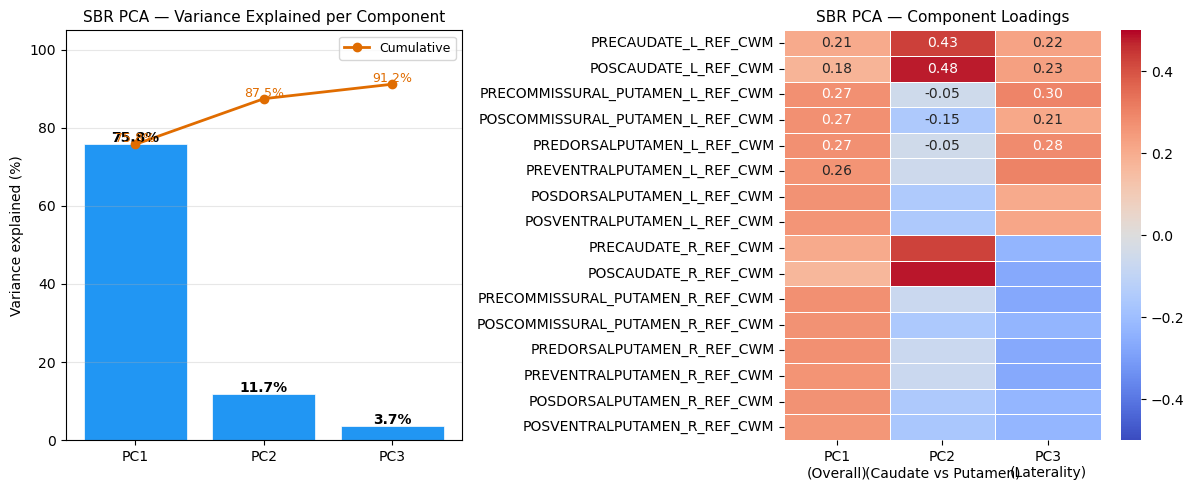

Saved: sbr_pca_variance.png


In [48]:
# [SBR-PCA-VARIANCE-PLOT]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 — variance explained
pcs     = [f'PC{i+1}' for i in range(N_SBR_PCS)]
var_pct = pca_sbr.explained_variance_ratio_ * 100
cum_var = np.cumsum(var_pct)

axes[0].bar(pcs, var_pct, color='#2196F3', edgecolor='white', linewidth=0.5)
axes[0].plot(pcs, cum_var, 'o-', color='#e06c00', linewidth=2, label='Cumulative')
for i, (v, c) in enumerate(zip(var_pct, cum_var)):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
    axes[0].text(i, c + 0.5, f'{c:.1f}%', ha='center', fontsize=9, color='#e06c00')
axes[0].set_ylabel('Variance explained (%)', fontsize=10)
axes[0].set_title('SBR PCA — Variance Explained per Component', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 105)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2 — loadings heatmap
sns.heatmap(
    loadings,
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-0.5, vmax=0.5,
    linewidths=0.5, ax=axes[1]
)
axes[1].set_title('SBR PCA — Component Loadings', fontsize=11)
axes[1].set_xticklabels(['PC1\n(Overall)', 'PC2\n(Caudate vs Putamen)', 'PC3\n(Laterality)'])

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}sbr_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: sbr_pca_variance.png")

## 5. Coverage Report
What is it?
We check how many rows in our train and val files can be matched to an SBR score from the Xing file. Not every scan will have a match — some patients may not have SBR data at that specific visit.

Why does it matter?
If coverage is too low, the SBR PCA results won't be useful for the correlation analysis.

How we match:
Using PATNO + EVENT_ID — the same patient at the same visit.

In [49]:
# # [SBR-COVERAGE]

# df_train = pd.read_csv(TRAIN_FILE)
# df_val   = pd.read_csv(VAL_FILE)

# print(df_train.columns)

# # Match on PATNO + EVENT_ID
# df_sbr_slim = df_sbr[['PATNO', 'EVENT_ID'] + [f'SBR_XING_PC{i+1}'
#  for i in range(N_SBR_PCS)]]

# train_merged = df_train.merge(df_sbr_slim, on=['PATNO', 'EVENT_ID'], how='left')
# val_merged   = df_val.merge(df_sbr_slim,   on=['PATNO', 'EVENT_ID'], how='left')

# print("=== SBR coverage after merge ===")
# for name, df_m in [('Train', train_merged), ('Val', val_merged)]:
#     n     = df_m['SBR_XING_PC1'].notna().sum()
#     total = len(df_m)
#     print(f"  {name}: {n} / {total} rows matched ({n/total*100:.1f}%)")

## 6. Load UPDRS-III for PCA


In [50]:
# [LOAD-UPDRS3-FOR-PCA]

df_updrs3_raw = pd.read_csv(UPDRS_III_FILE, low_memory=False)

# All NP3 item columns — excluding NP3TOT which is the sum
NP3_ITEMS = [c for c in df_updrs3_raw.columns
             if c.startswith('NP3') and c != 'NP3TOT']

print("=== UPDRS-III for PCA ===")
print(f"Total NP3 item columns found: {len(NP3_ITEMS)}")
print(f"Items: {NP3_ITEMS}")

# Apply OFF state filter — same as notebook 5.0
df_updrs3 = df_updrs3_raw[
    (df_updrs3_raw['PDSTATE'] == 'OFF') | (df_updrs3_raw['PDSTATE'].isna())
].copy()

print(f"\nRows after OFF state filter: {len(df_updrs3)}")
print(f"Unique patients: {df_updrs3['PATNO'].nunique()}")

=== UPDRS-III for PCA ===
Total NP3 item columns found: 33
Items: ['NP3SPCH', 'NP3FACXP', 'NP3RIGN', 'NP3RIGRU', 'NP3RIGLU', 'NP3RIGRL', 'NP3RIGLL', 'NP3FTAPR', 'NP3FTAPL', 'NP3HMOVR', 'NP3HMOVL', 'NP3PRSPR', 'NP3PRSPL', 'NP3TTAPR', 'NP3TTAPL', 'NP3LGAGR', 'NP3LGAGL', 'NP3RISNG', 'NP3GAIT', 'NP3FRZGT', 'NP3PSTBL', 'NP3POSTR', 'NP3BRADY', 'NP3PTRMR', 'NP3PTRML', 'NP3KTRMR', 'NP3KTRML', 'NP3RTARU', 'NP3RTALU', 'NP3RTARL', 'NP3RTALL', 'NP3RTALJ', 'NP3RTCON']

Rows after OFF state filter: 28824
Unique patients: 5223


## 7. Clean and run PCA

In [51]:
# [UPDRS3-PCA]

# Drop rows with missing values in any NP3 item
df_np3 = df_updrs3[['PATNO', 'EVENT_ID', 'NP3TOT'] + NP3_ITEMS].dropna().copy()

print(f"Rows with complete NP3 items: {len(df_np3)}")
print(f"Unique patients:              {df_np3['PATNO'].nunique()}")

# Fit StandardScaler and PCA
scaler_np3 = StandardScaler()
np3_scaled = scaler_np3.fit_transform(df_np3[NP3_ITEMS])

pca_np3  = PCA(n_components=N_NP3_PCS, random_state=42)
np3_pcs  = pca_np3.fit_transform(np3_scaled)

for i in range(N_NP3_PCS):
    df_np3[f'NP3_PC{i+1}'] = np3_pcs[:, i]

print(f"\n=== UPDRS-III PCA results ===")
print(f"\nVariance explained per component:")
for i, var in enumerate(pca_np3.explained_variance_ratio_):
    print(f"  PC{i+1}: {var*100:.1f}%")
print(f"  Total: {pca_np3.explained_variance_ratio_.sum()*100:.1f}%")

# Save fitted objects
with open(f'{MODELS_DIR}scaler_np3.pkl', 'wb') as f: pickle.dump(scaler_np3, f)
with open(f'{MODELS_DIR}pca_np3.pkl',   'wb') as f: pickle.dump(pca_np3,    f)
print(f"\nSaved: scaler_np3.pkl, pca_np3.pkl")

Rows with complete NP3 items: 23405
Unique patients:              5151

=== UPDRS-III PCA results ===

Variance explained per component:
  PC1: 37.4%
  PC2: 7.8%
  PC3: 7.5%
  Total: 52.7%

Saved: scaler_np3.pkl, pca_np3.pkl


## 8. Sanity Check

What it does: PC1 should be almost perfectly correlated with NP3TOT. This is our sanity check — if PC1 is NOT highly correlated with NP3TOT, something went wrong.

In [52]:
# [SANITY-CHECK-PC1-VS-NP3TOT]

r, p = stats.pearsonr(df_np3['NP3_PC1'], df_np3['NP3TOT'])

print("=== Sanity check: NP3_PC1 vs NP3TOT ===")
print(f"Pearson r:  {r:.4f}")
print(f"r²:         {r**2:.4f}")
print(f"p-value:    {p:.2e}")

if abs(r) > 0.95:
    print("\n PC1 is highly correlated with NP3TOT — sanity check passed")
else:
    print("\n PC1 correlation with NP3TOT is lower than expected")

=== Sanity check: NP3_PC1 vs NP3TOT ===
Pearson r:  0.9973
r²:         0.9947
p-value:    0.00e+00

 PC1 is highly correlated with NP3TOT — sanity check passed


## 9. Laterality Check

What it does: Check what PC2 actually encodes by looking at its loadings. We expect right-side items to have opposite signs to left-side items — confirming PC2 captures which side of the body is more affected.

In [53]:
# [LATERALITY-CHECK-PC2]

# Build loadings dataframe
loadings_np3 = pd.DataFrame(
    pca_np3.components_.T,
    index=NP3_ITEMS,
    columns=[f'PC{i+1}' for i in range(N_NP3_PCS)]
).round(3)

# Separate right and left items
right_items = [c for c in NP3_ITEMS if c.endswith('R')]
left_items  = [c for c in NP3_ITEMS if c.endswith('L')]
bilateral   = [c for c in NP3_ITEMS if c not in right_items + left_items]

print("=== PC2 loadings by side ===")
print(f"\nRight-side items (PC2 loading):")
print(loadings_np3.loc[right_items, 'PC2'].to_string())
print(f"\nLeft-side items (PC2 loading):")
print(loadings_np3.loc[left_items, 'PC2'].to_string())
print(f"\nBilateral items (PC2 loading):")
print(loadings_np3.loc[bilateral, 'PC2'].to_string())

# Summary
right_mean = loadings_np3.loc[right_items, 'PC2'].mean()
left_mean  = loadings_np3.loc[left_items,  'PC2'].mean()
print(f"\nMean PC2 loading — Right items: {right_mean:.3f}")
print(f"Mean PC2 loading — Left items:  {left_mean:.3f}")

if right_mean * left_mean < 0:
    print("\nPC2 captures laterality — right and left items have opposite signs")
else:
    print("\n PC2 does not clearly separate right from left")

=== PC2 loadings by side ===

Right-side items (PC2 loading):
NP3FTAPR    0.144
NP3HMOVR    0.133
NP3PRSPR    0.155
NP3TTAPR    0.101
NP3LGAGR    0.029
NP3POSTR   -0.054
NP3PTRMR    0.371
NP3KTRMR    0.292

Left-side items (PC2 loading):
NP3RIGRL    0.079
NP3RIGLL   -0.160
NP3FTAPL   -0.201
NP3HMOVL   -0.206
NP3PRSPL   -0.212
NP3TTAPL   -0.206
NP3LGAGL   -0.208
NP3PSTBL   -0.122
NP3PTRML    0.055
NP3KTRML    0.073
NP3RTARL    0.267
NP3RTALL    0.032

Bilateral items (PC2 loading):
NP3SPCH    -0.056
NP3FACXP   -0.006
NP3RIGN    -0.029
NP3RIGRU    0.168
NP3RIGLU   -0.167
NP3RISNG   -0.120
NP3GAIT    -0.070
NP3FRZGT   -0.117
NP3BRADY   -0.029
NP3RTARU    0.422
NP3RTALU   -0.030
NP3RTALJ    0.126
NP3RTCON    0.267

Mean PC2 loading — Right items: 0.146
Mean PC2 loading — Left items:  -0.067

PC2 captures laterality — right and left items have opposite signs


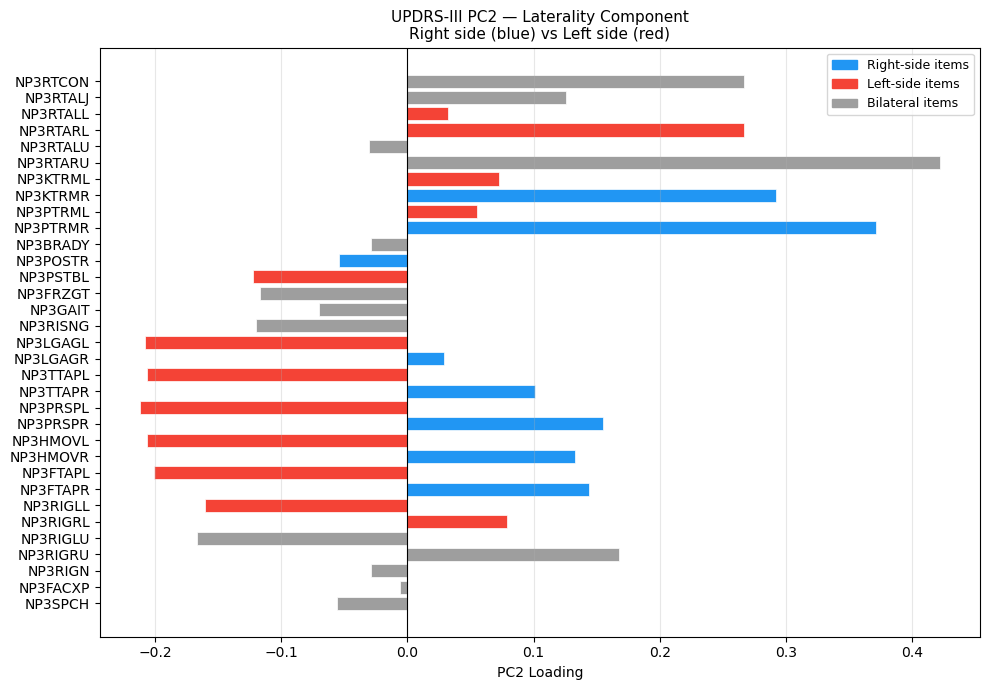

Saved: np3_pc2_laterality.png


In [54]:
# [LATERALITY-PLOT]

fig, ax = plt.subplots(figsize=(10, 7))

colors = []
for item in NP3_ITEMS:
    if item.endswith('R'):
        colors.append('#2196F3')   # blue = right
    elif item.endswith('L'):
        colors.append('#F44336')   # red = left
    else:
        colors.append('#9E9E9E')   # grey = bilateral

pc2_vals = loadings_np3['PC2'].values
bars = ax.barh(NP3_ITEMS, pc2_vals, color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('PC2 Loading', fontsize=10)
ax.set_title('UPDRS-III PC2 — Laterality Component\nRight side (blue) vs Left side (red)',
             fontsize=11)
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend = [
    Patch(color='#2196F3', label='Right-side items'),
    Patch(color='#F44336', label='Left-side items'),
    Patch(color='#9E9E9E', label='Bilateral items'),
]
ax.legend(handles=legend, fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}np3_pc2_laterality.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: np3_pc2_laterality.png")

## 10. Save Results and Summary

In [55]:
# [SAVE-RESULTS]

import os

# Save NP3 PCA results to CSV for use in downstream notebooks
df_np3_results = df_np3[['PATNO', 'EVENT_ID', 'NP3TOT',
                          'NP3_PC1', 'NP3_PC2', 'NP3_PC3']].copy()
df_np3_results.to_csv(f'{MODELS_DIR}np3_pca_scores.csv', index=False)

# Save SBR PCA results to CSV
df_sbr_results = df_sbr[['PATNO', 'EVENT_ID', 'DATSCAN_DATE',
                          'SBR_XING_PC1', 'SBR_XING_PC2', 'SBR_XING_PC3']].copy()
df_sbr_results.to_csv(f'{MODELS_DIR}sbr_xing_pca_scores.csv', index=False)

print("=== Files saved ===")
print(f"  np3_pca_scores.csv    — {len(df_np3_results)} rows, {df_np3_results['PATNO'].nunique()} patients")
print(f"  sbr_xing_pca_scores.csv — {len(df_sbr_results)} rows, {df_sbr_results['PATNO'].nunique()} patients")
print(f"  scaler_sbr_xing.pkl")
print(f"  pca_sbr_xing.pkl")
print(f"  scaler_np3.pkl")
print(f"  pca_np3.pkl")

=== Files saved ===
  np3_pca_scores.csv    — 23405 rows, 5151 patients
  sbr_xing_pca_scores.csv — 9949 rows, 4565 patients
  scaler_sbr_xing.pkl
  pca_sbr_xing.pkl
  scaler_np3.pkl
  pca_np3.pkl


In [56]:
# [SUMMARY]

print("=" * 60)
print("NOTEBOOK 5.3 SUMMARY")
print("=" * 60)

print("\n--- SBR PCA (Xing Core Lab) ---")
print(f"  Input:    16 regional columns (8L + 8R)")
print(f"  Patients: {df_sbr['PATNO'].nunique()}")
print(f"  PC1: {pca_sbr.explained_variance_ratio_[0]*100:.1f}% — Overall dopamine signal")
print(f"  PC2: {pca_sbr.explained_variance_ratio_[1]*100:.1f}% — Caudate vs Putamen")
print(f"  PC3: {pca_sbr.explained_variance_ratio_[2]*100:.1f}% — Laterality")
print(f"  Total: {pca_sbr.explained_variance_ratio_.sum()*100:.1f}%")

print("\n--- UPDRS-III PCA ---")
print(f"  Input:    33 NP3 items (OFF state, excluding NP3TOT)")
print(f"  Patients: {df_np3['PATNO'].nunique()}")
print(f"  PC1: {pca_np3.explained_variance_ratio_[0]*100:.1f}% — Overall motor severity")
print(f"       Correlation with NP3TOT: r = {stats.pearsonr(df_np3['NP3_PC1'], df_np3['NP3TOT'])[0]:.4f} ✓")
print(f"  PC2: {pca_np3.explained_variance_ratio_[1]*100:.1f}% — Laterality (right vs left)")
print(f"  PC3: {pca_np3.explained_variance_ratio_[2]*100:.1f}% — Additional variance")
print(f"  Total: {pca_np3.explained_variance_ratio_.sum()*100:.1f}%")

print("\n--- Next steps ---")
print("  DAI-128: Use SBR_XING_PC1/2/3 and NP3_PC1/2 in notebook 5.1")
print("  DAI-128: Compare VAE features vs SBR quantification")
print("  DAI-129: Swap corrected latent files when professor sends them")

NOTEBOOK 5.3 SUMMARY

--- SBR PCA (Xing Core Lab) ---
  Input:    16 regional columns (8L + 8R)
  Patients: 4565
  PC1: 75.8% — Overall dopamine signal
  PC2: 11.7% — Caudate vs Putamen
  PC3: 3.7% — Laterality
  Total: 91.2%

--- UPDRS-III PCA ---
  Input:    33 NP3 items (OFF state, excluding NP3TOT)
  Patients: 5151
  PC1: 37.4% — Overall motor severity
       Correlation with NP3TOT: r = 0.9973 ✓
  PC2: 7.8% — Laterality (right vs left)
  PC3: 7.5% — Additional variance
  Total: 52.7%

--- Next steps ---
  DAI-128: Use SBR_XING_PC1/2/3 and NP3_PC1/2 in notebook 5.1
  DAI-128: Compare VAE features vs SBR quantification
  DAI-129: Swap corrected latent files when professor sends them
